# HybridBayesTree

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/gtsam/hybrid/doc/HybridBayesTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass  # Not running on Colab, do nothing

A `HybridBayesTree` is the hybrid equivalent of a `gtsam.GaussianBayesTree`. It represents the result of **multifrontal** variable elimination on a `HybridGaussianFactorGraph`.

Like a standard Bayes tree, it's a tree structure where each node is a 'clique'. However, in a `HybridBayesTree`, each clique contains a `gtsam.HybridConditional` representing $P(F_k | S_k)$, where $F_k$ are the frontal variables eliminated in that clique, and $S_k$ are the separator variables shared with the parent clique.

In **hybrid** Bayes trees discrete variables can only occur as frontal variables if the separator is entirely discrete, i.e., we will never have the situation that a discrete variable is conditioned on a continuous variable.

The joint probability distribution $P(X, M)$ encoded by the tree is the product of all clique conditionals:
$$
P(X, M) = \prod_k P(F_k : S_k)
$$
Compared to a `HybridBayesNet` (from sequential elimination), a `HybridBayesTree` is (a) tree-structured, (b) often has a shallower structure. Both are advantageous for inference tasks like marginalization and incremental updates, especially in sparse problems common in robotics (SLAM).

In [2]:
import gtsam
import numpy as np

from gtsam import (
    HybridGaussianFactorGraph, 
    JacobianFactor, DecisionTreeFactor, HybridGaussianFactor,
    DiscreteValues
)
from gtsam.symbol_shorthand import X, D

import graphviz

## Creating a HybridBayesTree (via Elimination)

`HybridBayesTree` objects are obtained by performing **multifrontal** elimination on a `HybridGaussianFactorGraph`.

Original HybridGaussianFactorGraph:


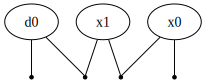


Elimination Ordering: Position 0: x0, x1, d0


Resulting HybridBayesTree:


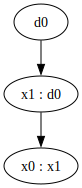

In [3]:
# --- Create a HybridGaussianFactorGraph ---
hgfg = HybridGaussianFactorGraph()
dk0 = (D(0), 2) # Binary discrete variable

# Prior on D0: P(D0=0)=0.6, P(D0=1)=0.4
prior_d0 = DecisionTreeFactor([dk0], "0.6 0.4")
hgfg.add(prior_d0)

# Prior on X0: P(X0) = N(0, 1)
prior_x0 = JacobianFactor(X(0), np.eye(1), np.zeros(1), gtsam.noiseModel.Isotropic.Sigma(1, 1.0))
hgfg.add(prior_x0)

# Conditional measurement on X1: P(X1 | D0)
# Mode 0: P(X1 | D0=0) = N(1, 0.25)
gf0 = JacobianFactor(X(1), np.eye(1), np.array([1.0]), gtsam.noiseModel.Isotropic.Sigma(1, 0.5))
# Mode 1: P(X1 | D0=1) = N(5, 1.0)
gf1 = JacobianFactor(X(1), np.eye(1), np.array([5.0]), gtsam.noiseModel.Isotropic.Sigma(1, 1.0))
meas_x1_d0 = HybridGaussianFactor(dk0, [gf0, gf1])
hgfg.add(meas_x1_d0)

# Factor connecting X0 and X1: P(X1 | X0) = N(X0+1, 0.1)
odom_x0_x1 = JacobianFactor(X(0), -np.eye(1), X(1), np.eye(1), np.array([1.0]), gtsam.noiseModel.Isotropic.Sigma(1, np.sqrt(0.1)))
hgfg.add(odom_x0_x1)

print("Original HybridGaussianFactorGraph:")
# hgfg.print()
display(graphviz.Source(hgfg.dot()))

# --- Elimination ---
# Use default hybrid ordering (continuous first, then discrete)
ordering = gtsam.HybridOrdering(hgfg)
print(f"\nElimination Ordering: {ordering}")

# Perform multifrontal elimination
hybrid_bayes_tree = hgfg.eliminateMultifrontal(ordering)

print("\nResulting HybridBayesTree:")
# hybrid_bayes_tree.print()
display(graphviz.Source(hybrid_bayes_tree.dot()))

## Operations on HybridBayesTree

Similar to `HybridBayesNet`, the tree can be used for optimization, evaluation, and extracting specific conditional distributions.

In [4]:
hbt = hybrid_bayes_tree # Use the tree from elimination

# --- Optimization (Finding MAP state) ---
# Computes MPE for discrete, then optimizes continuous given MPE
map_solution = hbt.optimize()
print("\nMAP Solution (Optimize):")
map_solution.print()

# --- MPE (Most Probable Explanation for Discrete Variables) ---
mpe_assignment = hbt.mpe()
print("\nMPE Discrete Assignment:")
print(mpe_assignment)


MAP Solution (Optimize):
HybridValues: 
  Continuous: 2 elements
  x0: 0
  x1: 1
  Discrete: (d0, 0)
  Nonlinear
Values with 0 values:

MPE Discrete Assignment:
DiscreteValues{7205759403792793600: 0}


In [5]:
# --- Optimize Continuous given specific Discrete Assignment ---
dv0 = DiscreteValues()
dv0[D(0)] = 0
cont_solution_d0_eq_0 = hbt.optimize(dv0)
print("\nOptimized Continuous Solution for D0=0:")
cont_solution_d0_eq_0.print()

dv1 = DiscreteValues()
dv1[D(0)] = 1
cont_solution_d0_eq_1 = hbt.optimize(dv1)
print("\nOptimized Continuous Solution for D0=1:")
cont_solution_d0_eq_1.print()

# --- Evaluation ---
# Evaluate error (sum of errors of clique conditionals)
total_error = hbt.error(map_solution)
print(f"\nTotal Error at MAP solution: {total_error}")


Optimized Continuous Solution for D0=0:
VectorValues: 2 elements
  x0: 0
  x1: 1

Optimized Continuous Solution for D0=1:
VectorValues: 2 elements
  x0: 1.90476
  x1: 3.09524

Total Error at MAP solution: 0.023412453920796855


In [6]:
# --- Extract Conditional Distributions ---
# Choose a specific GaussianBayesTree for a discrete assignment
gaussian_bayes_tree_d0_eq_0 = hbt.choose(dv0)
print("\nGaussianBayesTree for D0=0:")
gaussian_bayes_tree_d0_eq_0.print()
# display(graphviz.Source(gaussian_bayes_tree_d0_eq_0.dot()))


GaussianBayesTree for D0=0:
: cliques: 3, variables: 2
- p()
  R = Empty (0x0)
  d = Empty (0x1)
  mean: 0 elements
  logNormalizationConstant: -0
  No noise model
| - p(x1)
  R = [ 2.21565 ]
  d = [ 2.21565 ]
  mean: 1 elements
  x1: 1
  logNormalizationConstant: -0.123394
  No noise model
| | - p(x0 | x1)
  R = [ 3.31662 ]
  S[x1] = [ -3.01511 ]
  d = [ -3.01511 ]
  logNormalizationConstant: 0.280009
  No noise model
